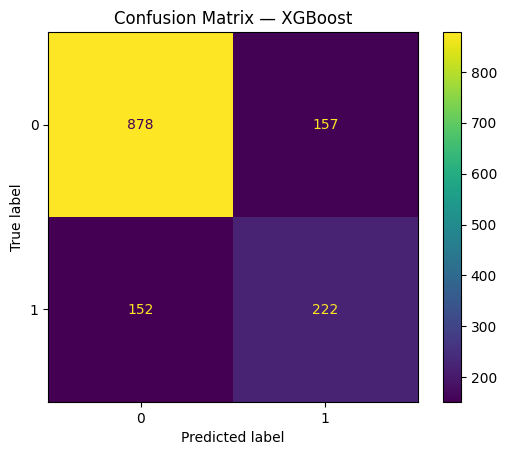

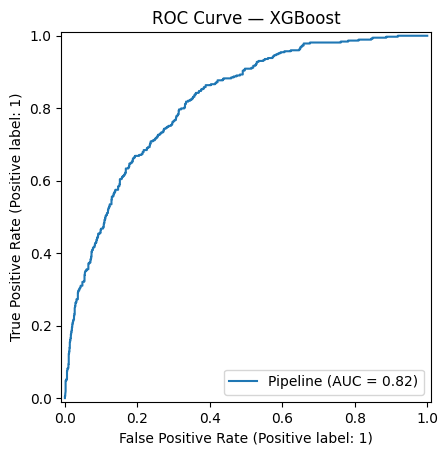

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

best_pipe = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(eval_metric="logloss", random_state=42))
])
best_pipe.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(best_pipe, X_test, y_test)
plt.title("Confusion Matrix — XGBoost")
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

RocCurveDisplay.from_estimator(best_pipe, X_test, y_test)
plt.title("ROC Curve — XGBoost")
plt.savefig("roc_curve.png", dpi=150)
plt.show()

In [10]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42)
}

results = []
for name, model in models.items():
    pipe = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, preds, output_dict=True)
    auc = roc_auc_score(y_test, probs)

    print(f"\n=== {name} ===")
    print(classification_report(y_test, preds))
    print(f"ROC-AUC: {auc:.4f}")

    results.append({
        "model": name,
        "precision_churn": round(report["1"]["precision"], 3),
        "recall_churn": round(report["1"]["recall"], 3),
        "f1_churn": round(report["1"]["f1-score"], 3),
        "roc_auc": round(auc, 4)
    })

results_df = pd.DataFrame(results)
print("\n=== Comparison ===")
print(results_df.to_string(index=False))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8400

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1035
           1       0.57      0.56      0.56       374

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409

ROC-AUC: 0.8162

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.59      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72    

In [9]:
!pip install imbalanced-learn xgboost -q


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = df.drop("Churn", axis=1)
y = df["Churn"]

num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(y_train.value_counts(normalize=True))

Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(df["TotalCharges"].isnull().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

# Remove customerID only if it still exists
df.drop("customerID", axis=1, inplace=True, errors="ignore")

# Convert Churn only if it's still Yes/No
if df["Churn"].dtype == "object":
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df.head())
print(df["Churn"].value_counts())

0
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No

In [4]:
import pandas as pd

df = pd.read_csv("churn.csv")

print(df.shape)
print(df["Churn"].value_counts())
print(df.dtypes)

(7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [3]:
import os
print(os.path.exists("churn.csv"))

True


In [2]:
!curl -o churn.csv https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv
!head -3 churn.csv


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  947k  100  947k    0     0  4419k      0 --:--:-- --:--:-- --:--:-- 4428k
customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [1]:
import pandas as pd

df = pd.read_csv("churn.csv")
print(df.shape)
print(df["Churn"].value_counts())
print(df.dtypes)

FileNotFoundError: [Errno 2] No such file or directory: 'churn.csv'

In [ ]:
!curl -o churn.csv https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv
!head -3 churn.csv


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  947k  100  947k    0     0  2075k      0 --:--:-- --:--:-- --:--:-- 2078k
customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
